In [39]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
Nx = 1
Ny = 2
N = Nx * Ny * 6

siteNum = np.zeros((Nx, Ny, 6))
sites =np.zeros((N, 3))
bondNum = N - 4*Nx
bondlist = np.zeros((bondNum, 2))

In [20]:
C=0

for i in range(Nx):
    for j in range(Ny):
        for k in range(6):
            siteNum[i][j][k] = C
            sites[C][0] = i
            sites[C][1] = j
            sites[C][2] = k
            C+=1

In [21]:

B = 3*N//2 # Maximum number of bonds possible (if both boundaries were periodic)
B+=-Ny #Boundary condition removes n possible bonds
site_num = np.zeros([Nx,Ny,6]) # Holds site indices
#site_num = np.empty(N,int)

 # Given site index, returns unit cell coordinates 
                             # and site number within the cell
bonds    = np.zeros([B,3])   # Given bond index, returns site numbers for sites
                             # on either side of the bonds and the bond type
b_num=0 #b_num will be used as an index for bonds, intialized to zero
neighbors = np.empty(3*N,int).reshape(N,3)



In [30]:
H = np.zeros((N, N))
t = 1.0

In [31]:
for i in range (N):
    for j in range (i+1, N):
        if (sites[i][0] == sites[j][0] and sites[i][1] == sites[j][1]):
            if ((sites[j][2] == sites [i][2] + 2 or sites[j][2] == sites [i][2] + 4)):
                print(i, j, "A")
                H[i,j] = -t
                H[j,i] = -t
            
                #continue 
            elif ((sites[i][2] == 3 and sites[j][2] == 4)):
                print(i,j, "B")
                H[i,j] = -t
                H[j,i] = -t
        
        if (sites[i][0] == sites[j][0] and sites[j][1] == sites[i][1]+1):
            if (sites[i][2] == 1 and (sites[j][2] == sites [i][2] + 2 or sites[j][2] == sites [i][2] + 3)):
                print(i,j, "C")
                H[i,j] = -t
                H[j,i] = -t
                
            elif (sites[i][2] == 0 and sites[j][2] == 2):
                print(i,j, "D")
                H[i,j] = -t
                H[j,i] = -t
                
        if (sites[i][1] == 0 and sites[j][1] == Ny - 1 and sites[i][0] == sites[j][0]):
            #print(i,j)
            #pass
            if (sites[i][2] == 2 and sites[j][2] == 0):
                print(i,j, "E")
                H[i,j] = -t
                H[j,i] = -t
                
            elif ((sites[i][2] == 3 or sites[i][2] == 4) and ( sites[j][2] == 1 )):
                print(i,j, "F")
                H[i,j] = -t
                H[j,i] = -t
            
        elif (sites[j][1] == sites[i][1] and sites[j][0] == sites[i][0]+1 and sites[i][2] == 2 and sites[j][2] == 5):
            print(i,j, "G")
            H[i,j] = -t
            H[j,i] = -t
            
        elif (sites[j][0] == sites[i][0]+1 and sites[j][1] == sites[i][1]+1 and sites[i][2] == 0 and sites[j][2] == 5):
            print(i,j, "H")
            H[i,j] = -t
            H[j,i] = -t
        elif (sites[i][1] == Ny - 1 and sites[j][1] == 0 and sites[j][0] == sites[i][0] + 1 and sites[i][2] == 0 and sites[j][2] == 5):
            print(i, j, "I")
            print(i,j, "G")
            H[i,j] = -t
            H[j,i] = -t

0 2 A
0 4 A
0 8 D
1 3 A
1 5 A
1 9 C
1 10 C
2 4 A
2 6 E
3 4 B
3 5 A
3 7 F
4 7 F
6 8 A
6 10 A
7 9 A
7 11 A
8 10 A
9 10 B
9 11 A


In [32]:
H

array([[ 0.,  0., -1.,  0., -1.,  0.,  0.,  0., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  0., -1.,  0.,  0.,  0., -1., -1.,  0.],
       [-1.,  0.,  0.,  0., -1.,  0., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  0.,  0., -1., -1.,  0., -1.,  0.,  0.,  0.,  0.],
       [-1.,  0., -1., -1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  0.,  0.,  0.,  0.,  0., -1.,  0., -1.,  0.],
       [ 0.,  0.,  0., -1., -1.,  0.,  0.,  0.,  0., -1.,  0., -1.],
       [-1.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0., -1.,  0.],
       [ 0., -1.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0., -1., -1.],
       [ 0., -1.,  0.,  0.,  0.,  0., -1.,  0., -1., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0., -1.,  0.,  0.]])

In [33]:
Eigen_Vals_and_Vecs = np.linalg.eigh(H) 

In [46]:
EigenVals = Eigen_Vals_and_Vecs[0]
EigenVecs = Eigen_Vals_and_Vecs[1]

In [41]:
EigenVals

array([-3.49721204e+00, -2.32813103e+00, -2.00000000e+00, -1.41421356e+00,
        3.17241037e-16,  7.25631216e-16,  3.28131026e-01,  1.41421356e+00,
        1.49721204e+00,  2.00000000e+00,  2.00000000e+00,  2.00000000e+00])

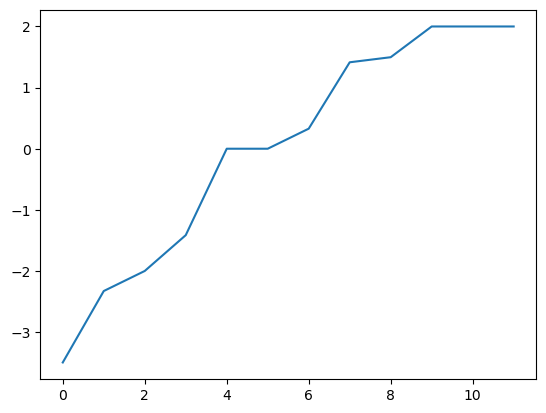

In [40]:
plt.plot(EigenVals)


Possible inputs: U, rho, t, t0/t1, Nx, Ny


In [49]:
EigenVecs[0]**2

array([4.83842391e-02, 1.58554710e-01, 6.25000000e-02, 5.11326181e-32,
       1.36650267e-02, 3.61334973e-01, 2.23469895e-02, 3.24828611e-32,
       2.07140615e-02, 4.27122052e-07, 3.11437557e-01, 1.06201629e-03])

In [56]:
p=0
for i in range (len(EigenVecs[0])):
    p += EigenVecs[0, i]**2
    

In [63]:
spins = np.zeros((N))
for i in range (len(EigenVecs[0])):
    spins[i] = 0.5 * (EigenVecs[0,i]**2)

In [64]:
spins  

array([2.41921195e-02, 7.92773550e-02, 3.12500000e-02, 2.55663090e-32,
       6.83251336e-03, 1.80667487e-01, 1.11734948e-02, 1.62414305e-32,
       1.03570308e-02, 2.13561026e-07, 1.55718778e-01, 5.31008145e-04])

In [14]:
for i in range (N):
    for j in range (i+1, N):
        if (sites[i][0] == sites[j][0] and sites[i][1] == sites[j][1]):
            if ((sites[j][2] == sites [i][2] + 2 or sites[j][2] == sites [i][2] + 4)):
                #print(i, j)
                pass
            elif ((sites[i][2] == 3 and sites[j][2] == 4)):
                #print(i,j)
                 pass
        
        elif (sites[i][0] == sites[j][0] and sites[j][1] == sites[i][1]+1 ):
            if (sites[i][2] == 1 and (sites[j][2] == sites [i][2] + 2 or sites[j][2] == sites [i][2] + 3)):
                #print(i,j)
                pass
            if (sites[i][2] == 0 and sites[j][2] == 2):
                #print(i,j)
                pass
        
            if (sites[i][2] == 2 and sites[j][2] == 2):
                #print(i,j)
                pass
        if (sites[i][1] == 0 and sites[j][1] == Ny - 1 and sites[i][0] == sites[j][0]):
            #print(i,j)
            if ((sites[i][2] == 4 or sites[i][2] == 3) and sites[j][2] == 1):
                print(i,j)
            elif(sites[i][2] == 2  and sites[j][2] == 0):
                print(i,j)